# Model Cross Data Validation
In this project I compare the results of three helmet detection CNN models using a fourth holdout dataset. Each model was trained on a different dataset, and the purpose of this project is to show how data quality influences final model performance in machine learning.

## Datasets Used
Four datasets were used in this project. Dataset0 was provided as part of a school project I did at UT, and Dataset1–3 are publicly available Kaggle datasets.

* Dataset0: Internal classification dataset (UT school project) Size ~600.
* Dataset1: Public Kaggle dataset (classification) Size ~500.
* Dataset2: Public Kaggle dataset (object detection with bounding boxes) Size ~250.
* Dataset3: Public Kaggle dataset (object detection with bounding boxes) Size ~2700.
* Holdout: A subset taken from Dataset2, and Dataset3 before training, reserved for cross-model validation.

### Data Preprocessing
Dataset0 and Dataset1 are classification databases, and for both these databases all images were resized to 200x200 prior to training.

Dataset1 and Dataset2 defined object location using bounding boxes. For these databases each bounding box was processed. A 100 x 100 pixel image was saved to our training dataset with the center of the object as close to the center of our training image as possible given the location in the source image.

A holdout set from Dataset2 and Dataset3 was saved prior to training for cross-model validation.

### Model Parameters
Model0 and Model1 both take a 200x200 image as their input image, and model2 takes a 100x100 input image.
Because these datasets were generated differently, they aren't directly comparable.

For the sake of model comparison, when evaluating model0 and model1 the validation data from dataset3 is resized to 200x200 prior to evaluation.

In [5]:
!pip install tensorflow==2.20.0 scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.4.1 pandas==2.2.2  kaggle-2.0.0-q

  Using cached tensorflow-2.20.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (4.5 kB)
  Using cached scikit_learn-1.6.1-cp313-cp313-macosx_12_0_arm64.whl.metadata (31 kB)
  Using cached opencv_python-4.12.0.88-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached numpy-2.4.1-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pandas-2.2.2-cp313-cp313-macosx_15_0_arm64.whl
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.26.0 Requires-Python <3.13,>=3.9; 1.26.1 Requires-Python <3.13,>=3.9
ERROR: Could not find a version that satisfies the requirement kaggle-2.0.0-q (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: 

In [6]:
# Helper Functions
import matplotlib.pyplot as plt
import cv2
import os
import pandas as pd
import tensorflow as tf
import numpy as np
from PIL import Image

tf.keras.utils.set_random_seed(42)


def correct_color(images):
    for i in range(len(images)):
        images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)


def load_image_paths_to_df(root_dir, image_size=(225, 225)):
    data = []

    for label in os.listdir(root_dir):
        label_path = os.path.join(root_dir, label)

        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    file_path = os.path.join(label_path, file)

                    data.append({
                        "label": label,
                        "file_path": file_path
                    })

    df = pd.DataFrame(data)
    return df


def convert_to_tf_dataset(df, image_size=(100, 100)):
    images = []
    labels = []
    for index, row in df.iterrows():
        file_path = row["file_path"]
        label = row["label_enum"]
        if os.path.exists(file_path):
            image = Image.open(file_path).convert("RGB")
            image = image.resize(image_size)
            image = np.array(image).astype('float32')
            images.append(image)
            labels.append(label)
        else:
            print(f"File not found: {file_path}")
    images = np.array(images)
    labels = np.array(labels)
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.map(lambda x, y: (tf.image.per_image_standardization(x), y)).batch(32)
    return dataset


In [7]:
# Loading Models

model0 = tf.keras.models.load_model("model/HelmNet_Image_Classification.v0.h5")
model1 = tf.keras.models.load_model("model/HelmNet_Image_Classification.v1.h5")
model2 = tf.keras.models.load_model("model/HelmNet_Image_Classification.v2.h5")
model3 = tf.keras.models.load_model("model/HelmNet_Image_Classification.v3.h5")

## Validation Dataset


In [8]:
dataset2_test = load_image_paths_to_df("data/dataset2_test")
dataset3_test = load_image_paths_to_df("data/dataset3_test").sample(n=50)

WITH_HELMET_LABEL = "with_helmet"
WITHOUT_HELMET_LABEL = "without_helmet"
WITHOUT_PERSON_LABEL = "without_person"

validation_dataframe = pd.concat([dataset3_test, dataset2_test], ignore_index=True)
validation_dataframe.shape


(100, 2)

In [9]:
validation_dataframe['label_enum'] = validation_dataframe['label'].replace({WITH_HELMET_LABEL: 1, WITHOUT_HELMET_LABEL: 0, WITHOUT_PERSON_LABEL: -1})
validation_dataframe = validation_dataframe[validation_dataframe['label_enum'] != -1]
validation_dataset1 = convert_to_tf_dataset(validation_dataframe, (200,200))
validation_dataset2 = convert_to_tf_dataset(validation_dataframe, (100,100))

/var/folders/tf/9kcph9b902v533j51hyt_46r0000gn/T/ipykernel_5079/3627649813.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validation_dataframe['label_enum'] = validation_dataframe['label'].replace({WITH_HELMET_LABEL: 1, WITHOUT_HELMET_LABEL: 0, WITHOUT_PERSON_LABEL: -1})


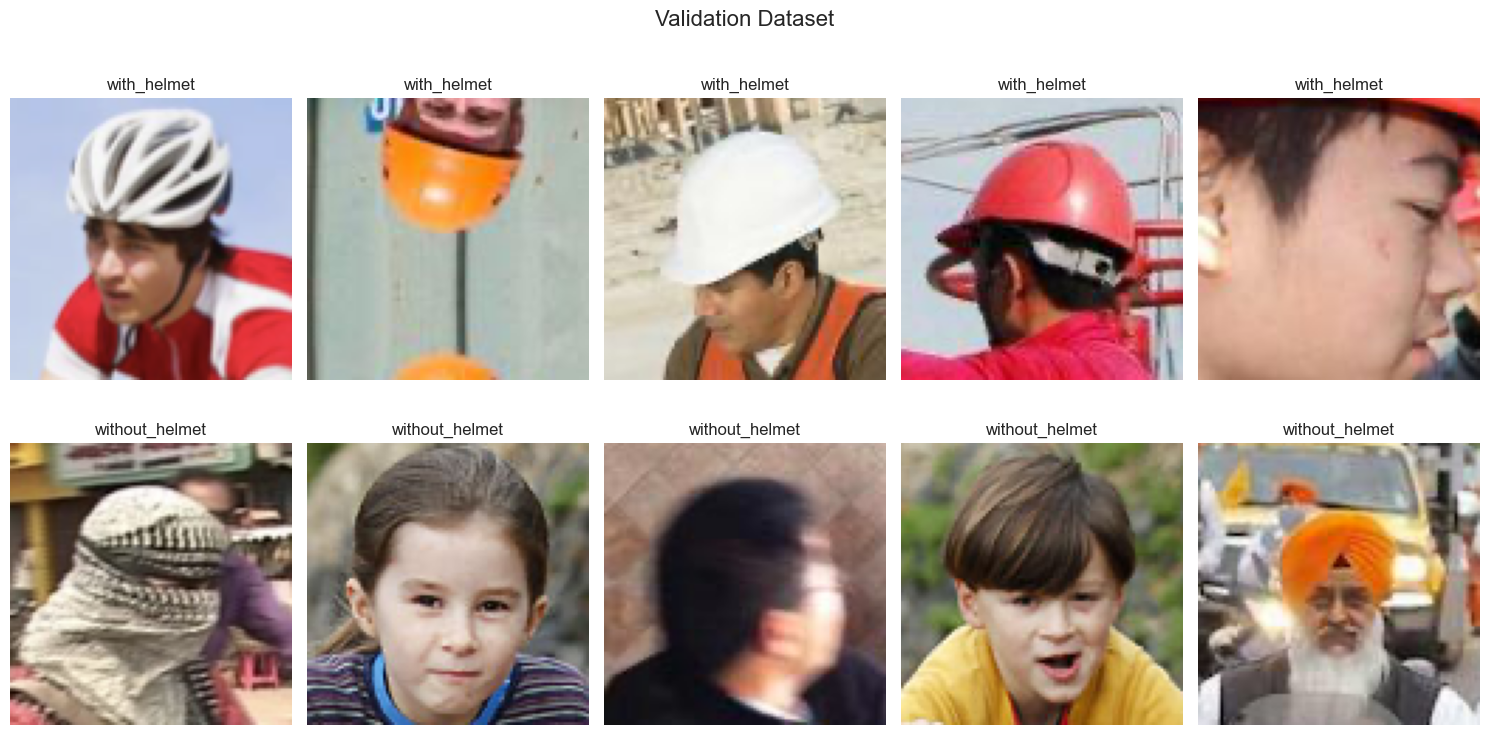

In [45]:
# Display 5 random images from each class
def display_validation_images(validation_df, title="Dataset",
                              figure_name='validation_sample_images.png', num_samples=5):
    # Group by labels
    grouped = validation_df.groupby("label")
    num_classes = len(grouped)

    fig, axes = plt.subplots(
        nrows=num_classes,
        ncols=num_samples,
        figsize=(15, 4 * num_classes)
    )
    axes = axes if num_classes > 1 else [axes]  # Handle single row case correctly

    for (label, group), ax_row in zip(grouped, axes):
        sampled_group = group.sample(n=min(num_samples, len(group)), random_state=42)
        for i, (_, row) in enumerate(sampled_group.iterrows()):
            img = Image.open(row["file_path"]).convert("RGB")
            ax_row[i].imshow(img)
            ax_row[i].axis("off")
            ax_row[i].set_title(label, fontsize=12)
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.savefig("charts/" + figure_name, bbox_inches="tight")
    plt.show()
display_validation_images(validation_dataframe, title="Validation Dataset", num_samples=5)

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
# Evaluate model0
y_true = np.concatenate([y.numpy() for _, y in validation_dataset1]).ravel()
y_pred_model0 = (model0.predict(validation_dataset1) > 0.5).astype("int32")

accuracy_model0 = accuracy_score(y_true, y_pred_model0)
precision_model0 = precision_score(y_true, y_pred_model0)
recall_model0 = recall_score(y_true, y_pred_model0)
f1_model0 = f1_score(y_true, y_pred_model0)

print(f"Model0 - Accuracy: {accuracy_model0}, Precision: {precision_model0}, Recall: {recall_model0}")

# Evaluate model1
y_pred_model1 = (model1.predict(validation_dataset1) > 0.5).astype("int32")

accuracy_model1 = accuracy_score(y_true, y_pred_model1)
precision_model1 = precision_score(y_true, y_pred_model1)
recall_model1 = recall_score(y_true, y_pred_model1)
f1_model1 = f1_score(y_true, y_pred_model1)

print(f"Model1 - Accuracy: {accuracy_model1}, Precision: {precision_model1}, Recall: {recall_model1}")

# Evaluate model2
y_pred_model2 = (model2.predict(validation_dataset2) > 0.5).astype("int32")

accuracy_model2 = accuracy_score(y_true, y_pred_model2)
precision_model2 = precision_score(y_true, y_pred_model2)
recall_model2 = recall_score(y_true, y_pred_model2)
f1_model2 = f1_score(y_true, y_pred_model2)

print(f"Model2 - Accuracy: {accuracy_model2}, Precision: {precision_model2}, Recall: {recall_model2}")


# Evaluate model3
y_pred_model3 = (model3.predict(validation_dataset2) > 0.5).astype("int32")

accuracy_model3 = accuracy_score(y_true, y_pred_model3)
precision_model3 = precision_score(y_true, y_pred_model3)
recall_model3 = recall_score(y_true, y_pred_model3)
f1_model3 = f1_score(y_true, y_pred_model3)

print(f"Model3 - Accuracy: {accuracy_model3}, Precision: {precision_model3}, Recall: {recall_model3}")



4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step
Model0 - Accuracy: 0.76, Precision: 0.8902439024390244, Recall: 0.8295454545454546
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step
Model1 - Accuracy: 0.66, Precision: 0.9821428571428571, Recall: 0.625


3/4 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x12dd102c0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 768ms/step
Model2 - Accuracy: 0.94, Precision: 0.9361702127659575, Recall: 1.0
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 770ms/step
Model3 - Accuracy: 0.92, Precision: 0.9545454545454546, Recall: 0.9545454545454546


In [12]:
df_validation_results = pd.DataFrame({
    "Model": ["Model0", "Model1", "Model2", "Model3"],
    "Accuracy": [accuracy_model0, accuracy_model1, accuracy_model2, accuracy_model3],
    "Precision": [precision_model0, precision_model1, precision_model2, precision_model3],
    "Recall": [recall_model0, recall_model1, recall_model2, recall_model3],
    "F1-Score": [f1_model0, f1_model1, f1_model2, f1_model3],
})
df_validation_results.sort_values(by="F1-Score", ascending=False, inplace=True)
df_validation_results

,Model,Accuracy,Precision,Recall,F1-Score
2,Model2,0.94,0.936170,1.000000,0.967033
3,Model3,0.92,0.954545,0.954545,0.954545
0,Model0,0.76,0.890244,0.829545,0.858824
1,Model1,0.66,0.982143,0.625000,0.763889


 # Conclusion
The performance of Model2 and Model3 are close with Model2 performing slightly better on the final validation set.

Model3 was a significantly bigger dataset, but contained a lot of inverted or mirrored images. This might have contributed to the worse performance. Also, most of the no-helmet samples in Dataset3 were managers, so it is possible the model learned to attribute nicer clothing to that class. Given the small size of the validation set, it's important not to read too much into these results.

After the validation data was normalized, the performance of Model0 improved enough surpassed Model1 on all metrics. This was surprising given how limited the no-helmet class was in this dataset. Model1 consisted of only two individuals and were taken by hand but on initial inspection still felt like a higher quality dataset than Dataset0.